In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Install all packages from
!pip install -r ../requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: '../requirements.txt'


In [3]:
import os, csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# !!!global!!!
plt.style.use('default')
# plt.style.use('dark_background')

Download stats analysis:

In [5]:
# Load stats/download_stats.csv and do analysis

df = pd.read_csv("../../stats/download_stats.csv")
df.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23972\2708885250.py:3: DtypeWarning: Columns (8,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../stats/download_stats.csv")


,recid,file,bytes,start,end,duration_s,rate_Bps,success,error,expected_size,expected_checksum,computed_checksum_numeric,checksum_ok,attempts
0,80504,../../data/80504/dst_content.pdf,249069.0,1.776449e+09,1.776449e+09,0.312649,7.966421e+05,True,NaN,249069.0,adler32:e59d20b1,3.852280e+09,True,1
1,80511,../../data/80511/quality_checker_1992.txt.pdf,391442.0,1.776449e+09,1.776449e+09,0.184401,2.122776e+06,True,NaN,391442.0,adler32:67e578db,1.743092e+09,True,1
2,80509,../../data/80509/DBrunt.dat,20307968.0,1.776449e+09,1.776449e+09,0.774413,2.622370e+07,True,NaN,20307968.0,adler32:0190cfad,2.626756e+07,True,1
3,80508,../../data/80508/hpc-logbooks.pdf,3005255.0,1.776449e+09,1.776449e+09,0.543860,5.525791e+06,True,NaN,3005255.0,adler32:c852be75,3.360866e+09,True,1
4,80511,../../data/80511/das_maestro_1992.txt.pdf,312496.0,1.776449e+09,1.776449e+09,0.639473,4.886771e+05,True,NaN,312496.0,adler32:e3694358,3.815327e+09,True,1


In [6]:
# Ensure CSV header includes the new 'attempts' column to avoid tokenizing errors

csv_path = "../../stats/download_stats.csv"
expected_columns = ['recid','file','bytes','start','end','duration_s','rate_Bps',
                    'success','error','expected_size','expected_checksum',
                    'computed_checksum_numeric','checksum_ok','attempts']

if os.path.exists(csv_path):
    try:
        with open(csv_path, 'r', newline='', encoding='utf-8') as f:
            reader = csv.reader(f)
            header = next(reader, [])
    except Exception:
        header = []

    # If header differs from expected, rewrite only the header line to the expected columns.
    # This preserves existing data rows while making future reads/appends consistent.
    if header != expected_columns:
        with open(csv_path, 'r', encoding='utf-8') as f:
            lines = f.read().splitlines()
        if lines:
            lines[0] = ','.join(expected_columns)
        else:
            lines = [','.join(expected_columns)]
        outpath = csv_path.split('.')[0] + '_updated.csv'
        with open(outpath, 'w', encoding='utf-8', newline='') as f:
            f.write('\n'.join(lines) + '\n')

In [7]:
# print all column names
print(df.columns)

Index(['recid', 'file', 'bytes', 'start', 'end', 'duration_s', 'rate_Bps',
       'success', 'error', 'expected_size', 'expected_checksum',
       'computed_checksum_numeric', 'checksum_ok', 'attempts'],
      dtype='object')


In [8]:
# total size of data in num of unique recids, Gb, average speed, total data, total time spent downloading, errors, etc.

# Index(['recid', 'file', 'bytes', 'start', 'end', 'duration_s', 'rate_Bps',
#       'success', 'error', 'expected_size', 'expected_checksum',
#       'computed_checksum_numeric', 'checksum_ok'],
#      dtype='object')

total_errors = df['success'].value_counts().get(False, 0)
df = df[df['success'] == True]  # Filter to only successful data for accurate stats
recids = df['recid'].nunique()
total_size = df['bytes'].sum()
average_download_speed = df['rate_Bps'].mean()
total_time_spent = df['end'].max() - df['start'].min()
average_speed = total_size / total_time_spent
total_downloads = len(df)

print(f"Downloaded unique recids: {recids}")
print(f"Total size of downloads: {total_size / (1024**3)} GB")
print(f"Average download speed: {average_download_speed / (1024**2)} MBps")
print(f"Average speed (total size / total time): {average_speed / (1024**2)} MBps")
print(f"Total downloads: {total_downloads}")
print(f"Total time spent downloading: {total_time_spent/3600} hours")
print(f"Total errors: {total_errors}")

Downloaded unique recids: 12711
Total size of downloads: 32227.934175337665 GB
Average download speed: 26.022418675438193 MBps
Average speed (total size / total time): 125.09018511010014 MBps
Total downloads: 415425
Total time spent downloading: 73.2835819535123 hours
Total errors: 115


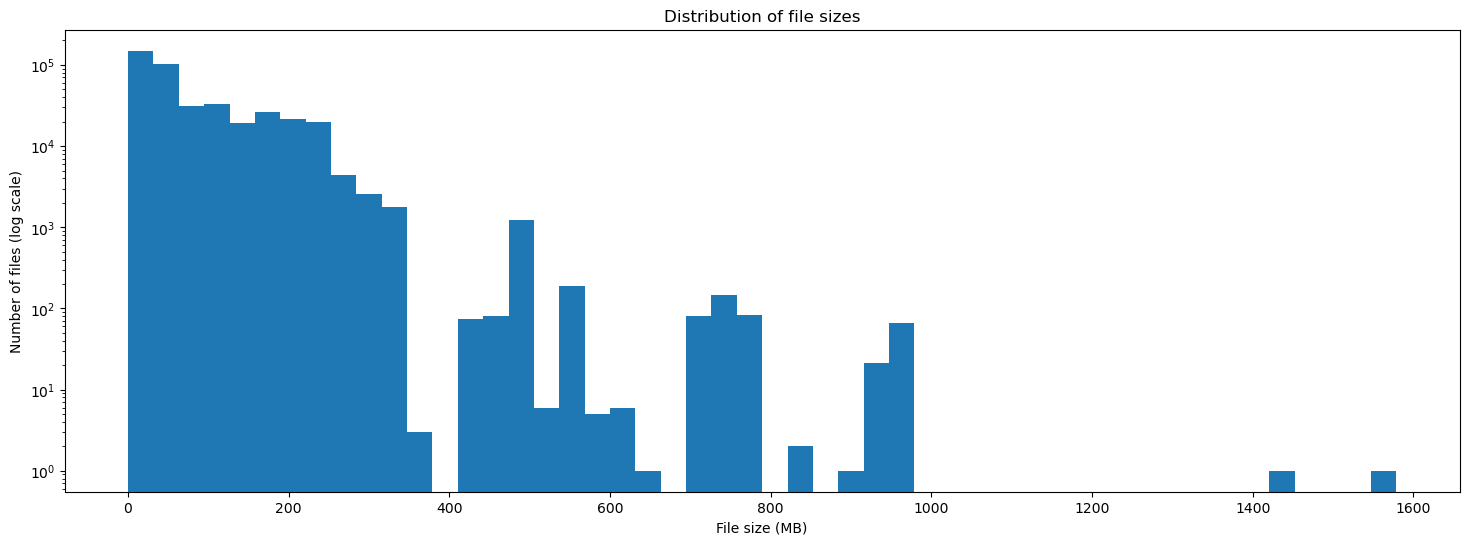

In [9]:
# Plot histogram of download sizes, x logarithmic, in MB, with 50 bins, label axes, title, etc.
plt.figure(figsize=(18, 6))
plt.hist(df['bytes'] / (1024**2), bins=50, log=True)
plt.xlabel('File size (MB)')
plt.ylabel('Number of files (log scale)')
plt.title('Distribution of file sizes')
# plt.savefig('../../figs/download_size_distribution.png', bbox_inches='tight')
plt.show()

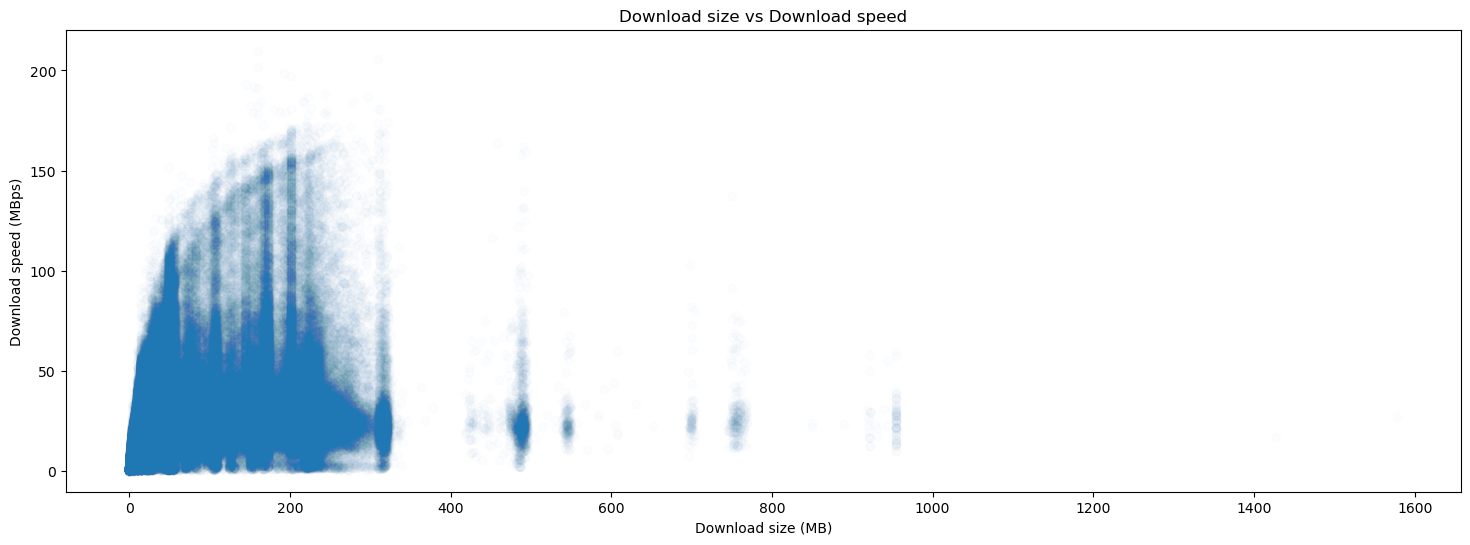

In [10]:
# Correlation between download size and download speed
plt.figure(figsize=(18, 6))
plt.scatter(df['bytes'] / (1024**2), df['rate_Bps'] / (1024**2), alpha=0.01)
plt.xlabel('Download size (MB)')
plt.ylabel('Download speed (MBps)')
plt.title('Download size vs Download speed')
# plt.savefig('../../figs/download_size_vs_speed.png', bbox_inches='tight')
plt.show()

In [11]:
# print ordered bins of 50 from distribution of number of files per recid, skip empty bins
files_per_recid = df['recid'].value_counts()

print(files_per_recid.max())

bins = pd.cut(files_per_recid, bins=range(0, files_per_recid.max() + 50, 20))
binned_counts = files_per_recid.groupby(bins).size()
binned_countsf = binned_counts[binned_counts.values != 0]
print(binned_countsf)

9000
count
(0, 20]         11662
(20, 40]          315
(40, 60]          136
(60, 80]           77
(80, 100]          94
                ...  
(5520, 5540]        1
(5960, 5980]        1
(5980, 6000]        3
(8240, 8260]        1
(8980, 9000]        1
Name: count, Length: 77, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23972\1897946637.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_counts = files_per_recid.groupby(bins).size()


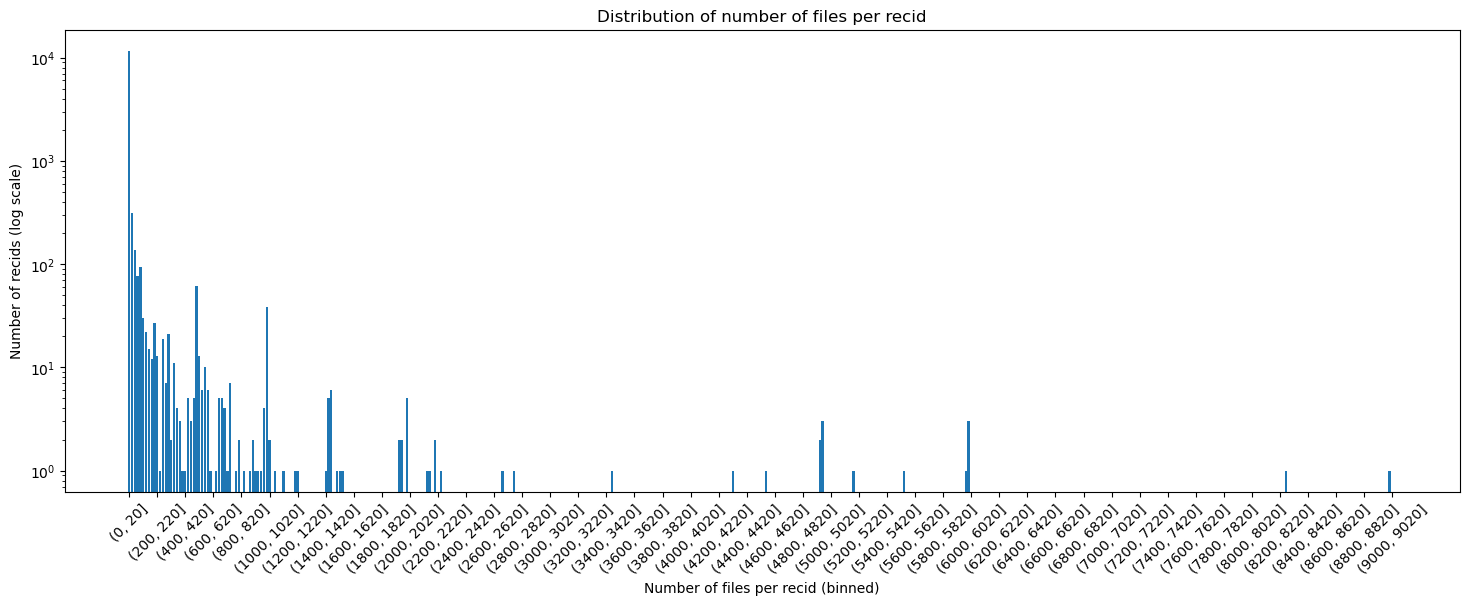

In [12]:
# plot the bins on a log scale, wide graph, modify tics - print every tenth label
plt.figure(figsize=(18, 6))
plt.bar(binned_counts.index.astype(str), binned_counts.values)
plt.yscale('log')
plt.xlabel('Number of files per recid (binned)')
plt.ylabel('Number of recids (log scale)')
plt.title('Distribution of number of files per recid')
plt.xticks(rotation=45)
plt.gca().set_xticks(plt.gca().get_xticks()[::10])
# plt.savefig('../../figs/files_per_recid_distribution.png', bbox_inches='tight')
plt.show()

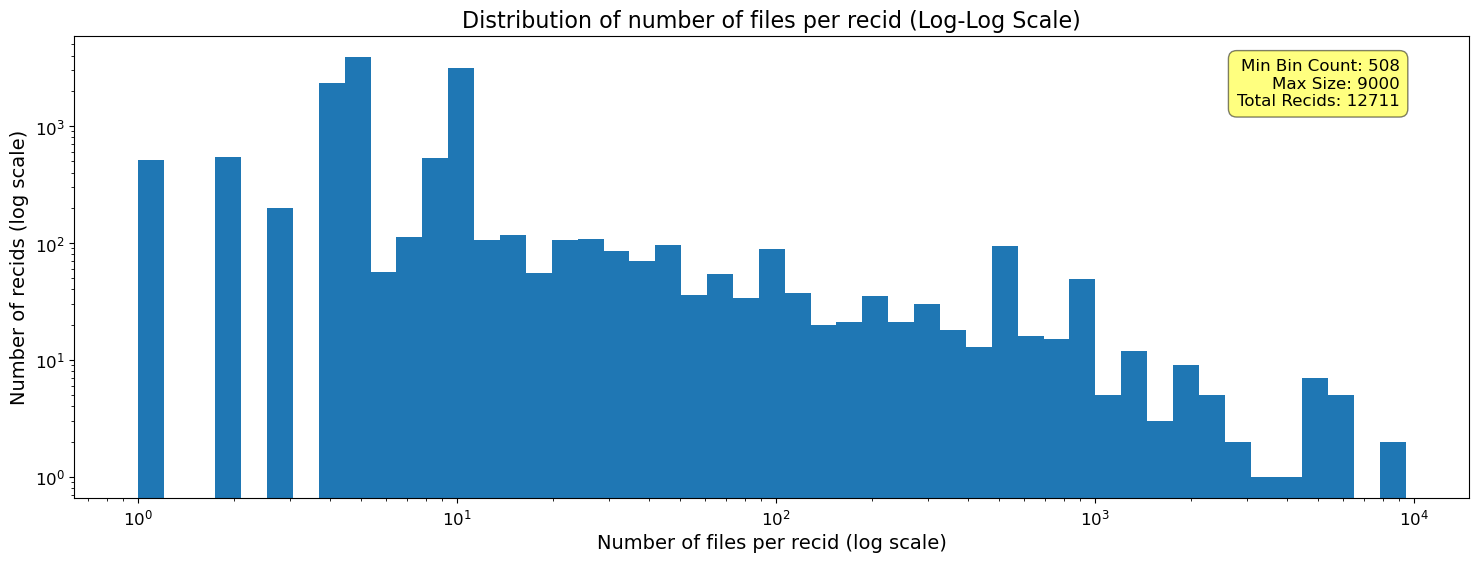

In [13]:
# plot the distribution of number of files per recid with logarithmic x-axis
plt.figure(figsize=(18, 6))

# Calculate logarithmic bins for the histogram
min_val = files_per_recid.min()
max_val = files_per_recid.max()
# Ensure min_val is at least 1 for log10, as counts cannot be 0
if min_val == 0:
    min_val = 1
# Create 50 logarithmically spaced bins, extending slightly beyond the max value
log_bins = np.logspace(np.log10(min_val), np.log10(max_val * 1.05), num=50)

# Plot the histogram with logarithmic x and y scales
n, bins, patches = plt.hist(files_per_recid.values, bins=log_bins, log=True)

plt.xscale('log') # Set x-axis to logarithmic scale
plt.yscale('log') # Keep y-axis to logarithmic scale

plt.xlabel('Number of files per recid (log scale)', fontsize=14)
plt.ylabel('Number of recids (log scale)', fontsize=14) # y-axis represents the count of recids within each file count bin
plt.title('Distribution of number of files per recid (Log-Log Scale)', fontsize=16)

# Increase font size for tick values
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)

# Add a text box with min bin value, max bin value, and total sum of bins
min_bin_value = n[0] if len(n) > 0 else 0
max_bin_value = n[-1] if len(n) > 0 else 0
total_recids_in_hist = int(n.sum())

text_str = f"Min Bin Count: {int(min_bin_value)}\n" \
           f"Max Size: {int(max_val)}\n" \
           f"Total Recids: {int(total_recids_in_hist)}"

plt.text(0.95, 0.95, text_str, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

# When using plt.xscale('log') with plt.hist, matplotlib typically handles ticks well automatically.
# Manual xtick adjustments are usually not needed and can interfere with the logarithmic scaling.

# plt.savefig('../../figs/files_per_recid_log_distribution.png', bbox_inches='tight')
plt.show()

<Figure size 1800x600 with 0 Axes>

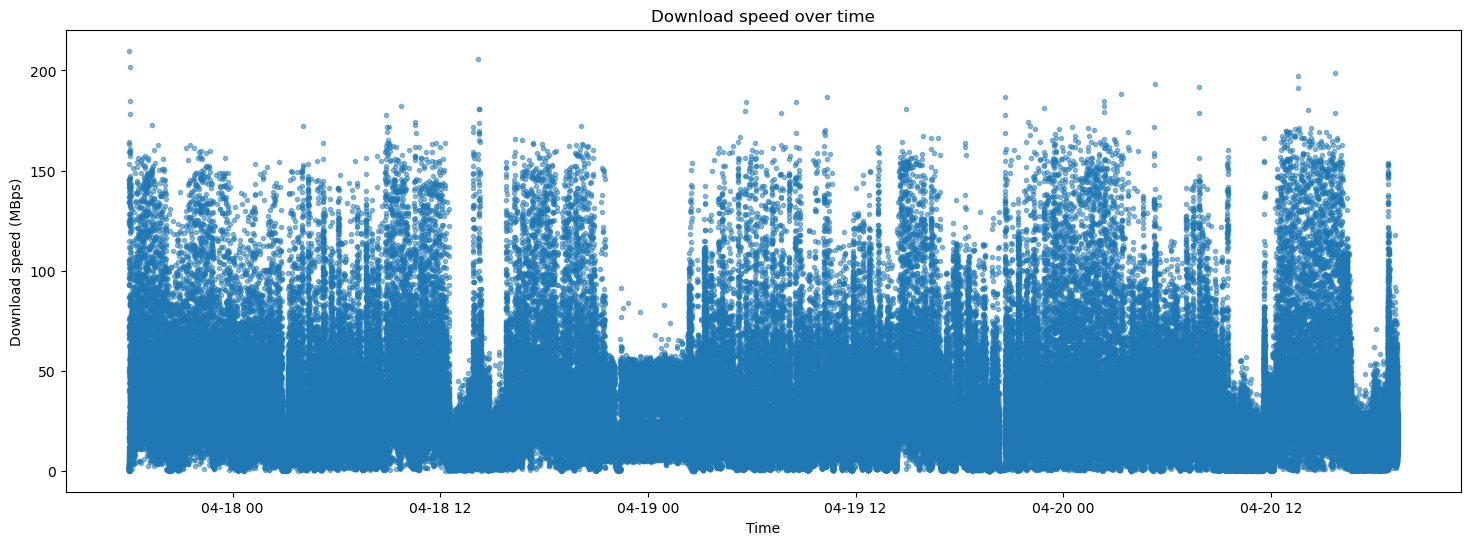

In [14]:
# plot download speed over time
plt.figure(figsize=(18, 6))
df['start_time'] = pd.to_datetime(df['start'], unit='s')
df = df.sort_values(by='start_time')
plt.figure(figsize=(18, 6))
plt.plot(df['start_time'], df['rate_Bps'] / (1024**2), marker='.', linestyle='None', alpha=0.5)
plt.xlabel('Time')
plt.ylabel('Download speed (MBps)')
plt.title('Download speed over time')
plt.show()

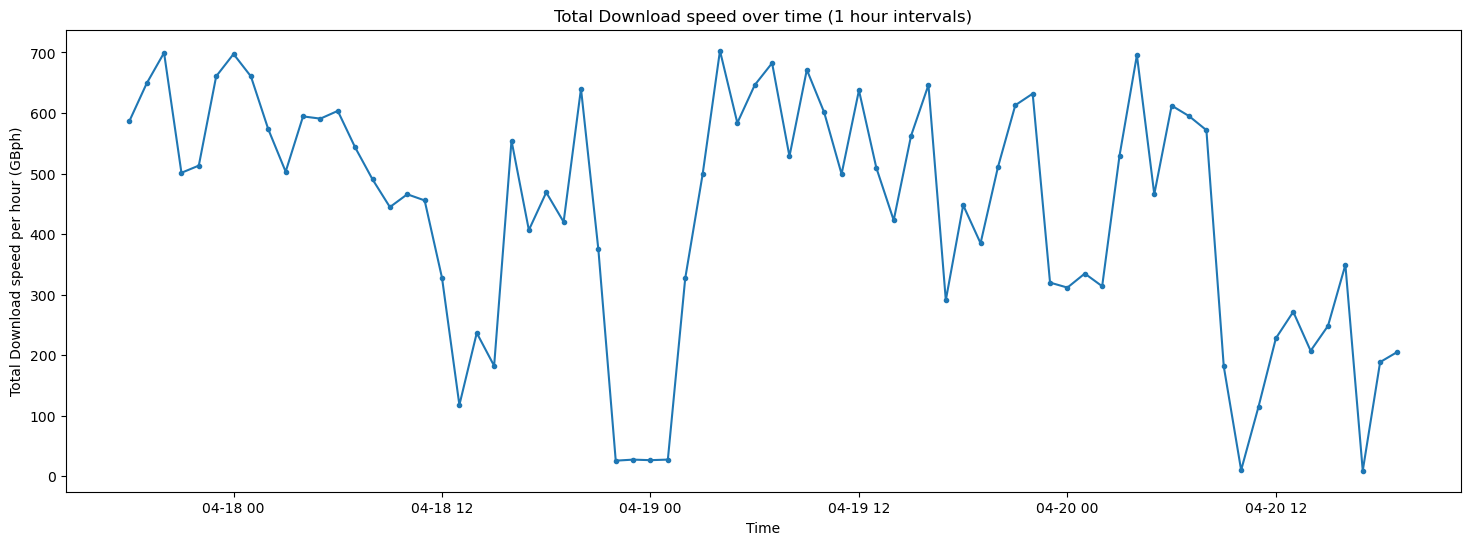

Average total download speed per hour: 435.5126239910495 GBph
Top 5 hours by total download speed (GBph):
2026-04-19 04:00:00: 702.7853384017944 GBps
2026-04-17 20:00:00: 699.4081947952509 GBps
2026-04-18 00:00:00: 697.3497198522091 GBps
2026-04-20 04:00:00: 695.4983997344971 GBps
2026-04-19 07:00:00: 682.3846435546875 GBps
Last 5 hours by total download speed (GBph):
2026-04-20 17:00:00: 9.199762344360352 GBps
2026-04-20 10:00:00: 10.178260803222656 GBps
2026-04-18 22:00:00: 25.808401107788086 GBps
2026-04-19 00:00:00: 26.61686897277832 GBps
2026-04-18 23:00:00: 27.526073455810547 GBps


In [15]:
# plot sum of download speed over one hour intervals
df['start_time_s'] = pd.to_datetime(df['start'], unit='s')
df2 = df.sort_values(by='start_time_s')
df2.set_index('start_time_s', inplace=True)
resampled = df2['bytes'].resample('1h').sum()
# resampled = resampled[resampled > 0]
plt.figure(figsize=(18, 6))
plt.plot(resampled.index, resampled.values / (1024**3), marker='.', linestyle='-')
plt.xlabel('Time')
plt.ylabel('Total Download speed per hour (GBph)')
plt.title('Total Download speed over time (1 hour intervals)')
# plt.savefig('../../figs/total_download_speed_per_hour.png', bbox_inches='tight')
plt.show()

# print info about top 5 hours with highest total download speed
top_hours = resampled.sort_values(ascending=False).head(5)
print(f"Average total download speed per hour: {resampled[resampled > 0].mean() / (1024**3)} GBph")
print("Top 5 hours by total download speed (GBph):")
for time, speed in top_hours.items():
    print(f"{time}: {speed / (1024**3)} GBps")
worst_hours = resampled.sort_values(ascending=True).head(5)
print("Last 5 hours by total download speed (GBph):")
for time, speed in worst_hours.items():
    print(f"{time}: {speed / (1024**3)} GBps")

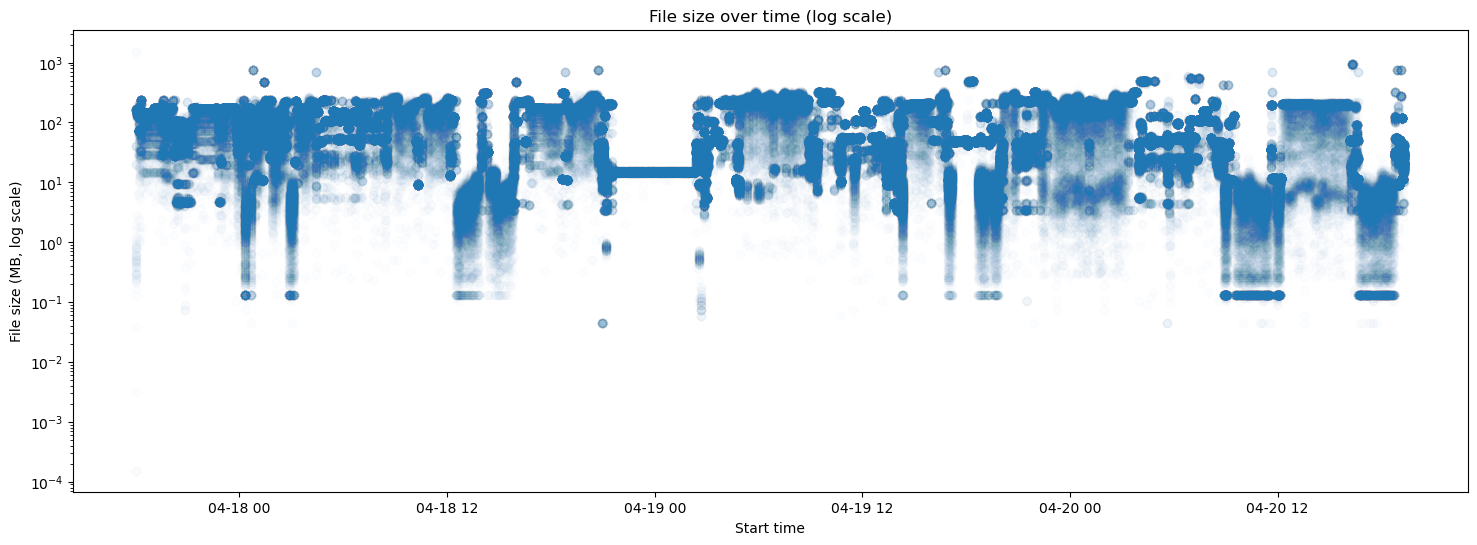

In [16]:
# Plot each file start time vs file size, with logarithmic y-axis
plt.figure(figsize=(18, 6))
plt.scatter(df['start_time'], df['bytes'] / (1024**2), alpha=0.01)
plt.yscale('log')
plt.xlabel('Start time')
plt.ylabel('File size (MB, log scale)')
plt.title('File size over time (log scale)')
# plt.savefig('../../figs/file_size_over_time_log.png', bbox_inches='tight')
plt.show()

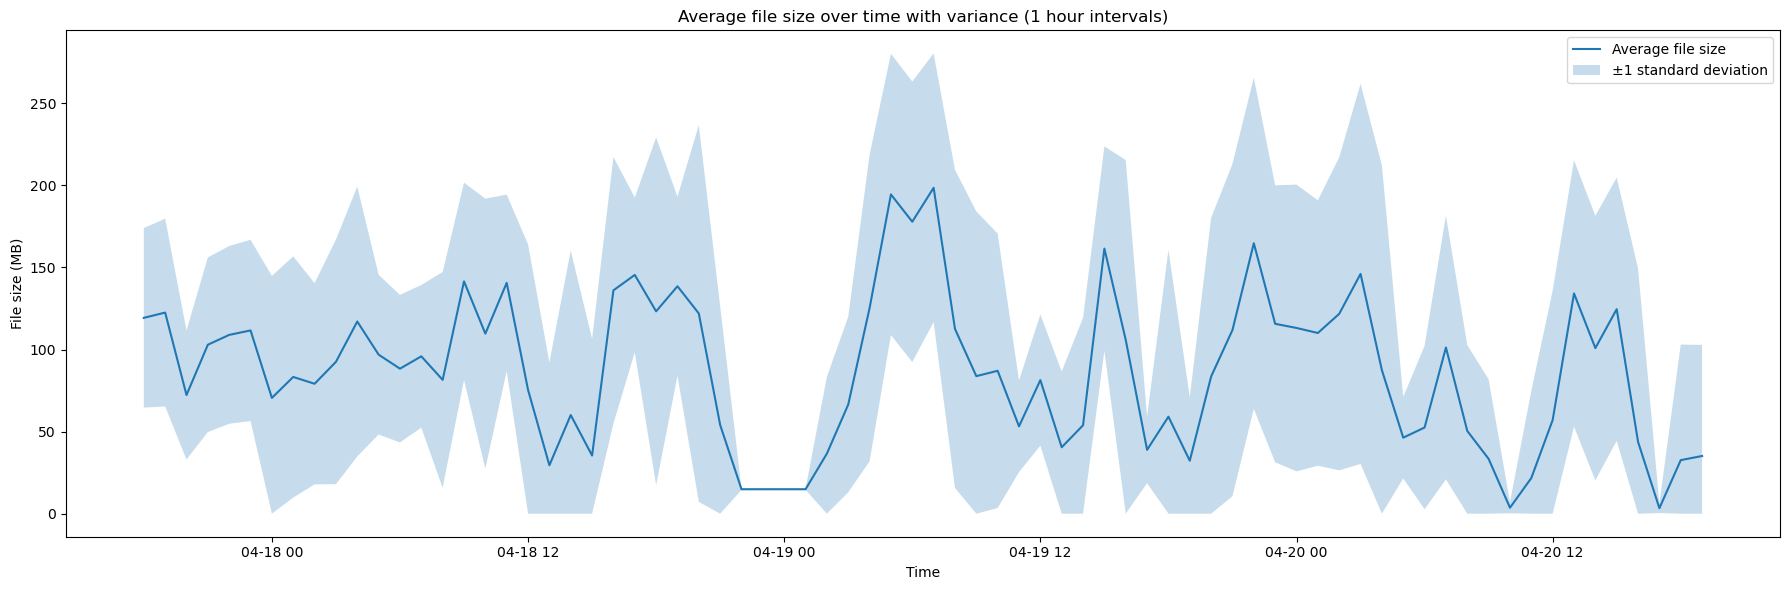

In [17]:
# plot average file size over time with variance

df['start_time_avg'] = pd.to_datetime(df['start'], unit='s')
df_avg = df[['start_time_avg', 'bytes']].sort_values('start_time_avg').set_index('start_time_avg')
hourly = df_avg['bytes'].resample('1h').agg(['mean', 'var', 'count'])
hourly = hourly[hourly['count'] > 0]
mean_mb = hourly['mean'] / (1024**2)
std_mb = np.sqrt(hourly['var'].fillna(0)) / (1024**2)

plt.figure(figsize=(18, 6))
plt.plot(hourly.index, mean_mb, label='Average file size')
plt.fill_between(hourly.index, (mean_mb - std_mb).clip(lower=0), mean_mb + std_mb, alpha=0.25, label='±1 standard deviation')
plt.xlabel('Time')
plt.ylabel('File size (MB)')
plt.title('Average file size over time with variance (1 hour intervals)')
plt.legend()
plt.tight_layout()
plt.show()



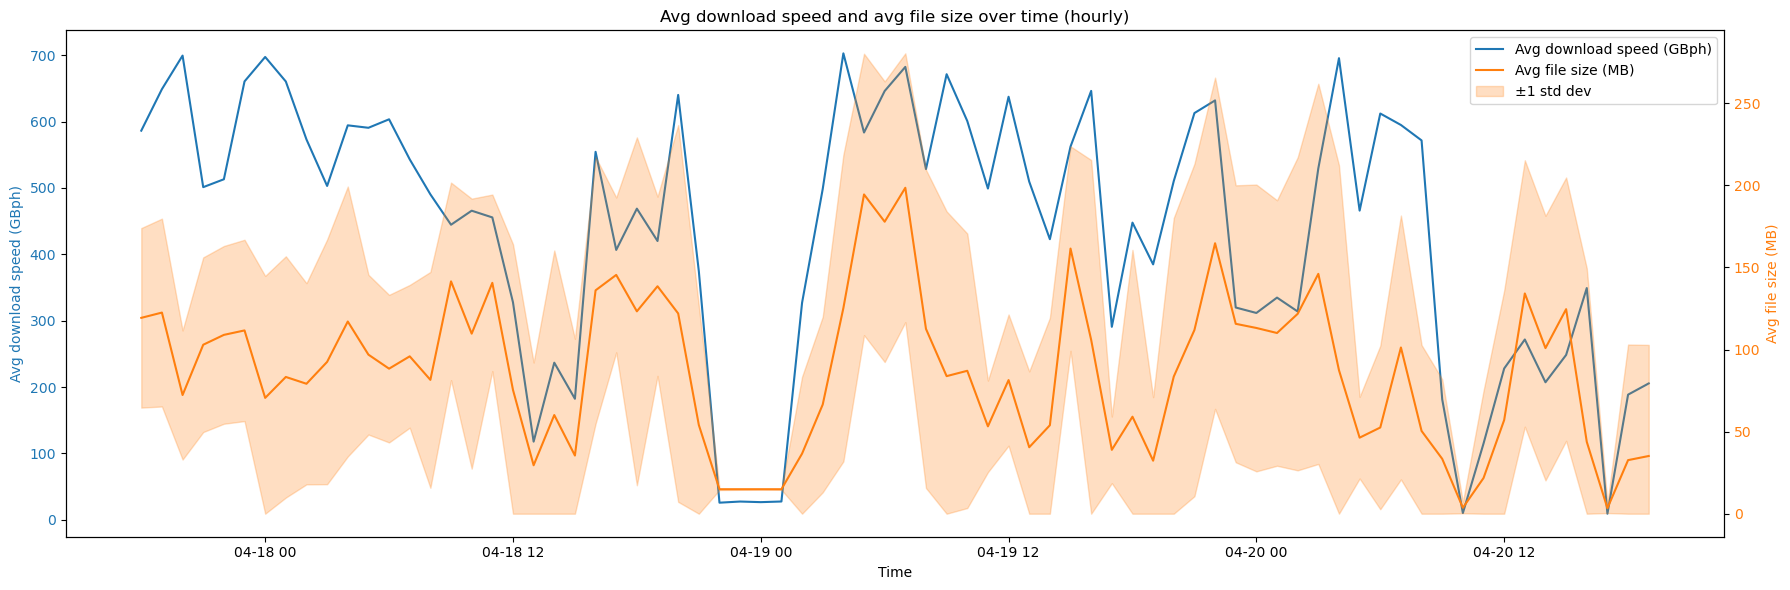

In [19]:
# Combine avg download speed (hourly) and avg file size (hourly)

# resampled: hourly total bytes (from your speed section)
# hourly: hourly mean/var bytes (from your avg file size section)

speed_gbph = resampled / (1024**3)  # GB per hour
mean_mb = hourly['mean'] / (1024**2)
std_mb = np.sqrt(hourly['var'].fillna(0)) / (1024**2)

fig, ax1 = plt.subplots(figsize=(18, 6))

# Avg download speed (left axis)
ax1.plot(speed_gbph.index, speed_gbph.values, color='tab:blue', label='Avg download speed (GBph)')
ax1.set_xlabel('Time')
ax1.set_ylabel('Avg download speed (GBph)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Avg file size with variance (right axis)
ax2 = ax1.twinx()
ax2.plot(mean_mb.index, mean_mb.values, color='tab:orange', label='Avg file size (MB)')
ax2.fill_between(mean_mb.index, (mean_mb - std_mb).clip(lower=0), mean_mb + std_mb,
                 alpha=0.25, color='tab:orange', label='±1 std dev')
ax2.set_ylabel('Avg file size (MB)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Avg download speed and avg file size over time (hourly)')
plt.tight_layout()
plt.show()

In [22]:
# Align hourly avg speed and hourly avg file size, then compute correlation
speed_gbph = (resampled / (1024**3)).rename('avg_speed_gbph')
avg_size_mb = (hourly['mean'] / (1024**2)).rename('avg_size_mb')

aligned = pd.concat([speed_gbph, avg_size_mb], axis=1).dropna()

pearson_corr = aligned['avg_speed_gbph'].corr(aligned['avg_size_mb'], method='pearson')
spearman_corr = aligned['avg_speed_gbph'].corr(aligned['avg_size_mb'], method='spearman')

print(f"Pearson correlation:  {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")
print(f"Aligned points: {len(aligned)}")

Pearson correlation:  0.6078
Spearman correlation: 0.5168
Aligned points: 74


In [25]:
# Correlation between download speed and file size deviation (hourly std dev)

speed_gbph = (resampled / (1024**3)).rename('avg_speed_gbph')
size_std_mb = (np.sqrt(hourly['var'].fillna(0)) / (1024**2)).rename('size_std_mb')

aligned = pd.concat([speed_gbph, size_std_mb], axis=1).dropna()

pearson_corr = aligned['avg_speed_gbph'].corr(aligned['size_std_mb'], method='pearson')
spearman_corr = aligned['avg_speed_gbph'].corr(aligned['size_std_mb'], method='spearman')

print(f"Pearson correlation:  {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")
print(f"Aligned points: {len(aligned)}")

Pearson correlation:  0.4689
Spearman correlation: 0.3243
Aligned points: 74
